# Expedia Review ROI, Sweepstakes Optimization, and Platform-Scale Business Case

This notebook estimates how much **more reviews** and **better reviews** could be worth to Expedia, compares that value to the cost of a **sweepstakes incentive**, and adds an all-in **GPT-4o mini** inference cost model for the adaptive review-question experience.

It is built around the prototype mechanic where:

- verified travelers answer adaptive review prompts
- each answered prompt adds a sweepstakes entry
- the product improves both review completion and review detail
- an LLM ranks the most useful follow-up questions before the traveler writes the review

The public Expedia and OpenAI facts are sourced. The conversion lift from better review coverage remains a transparent scenario assumption you can edit for the pitch.


## What This Version Adds

This version makes the financial logic easier to defend in a slide:

- a step-by-step bridge from **reward size -> more/better reviews -> bookings -> revenue**
- a **GPT-4o mini** cost estimate tied to the review-ranking flow in the prototype
- a **full-platform business case** with slide-ready metrics and a chart

The optimization target is the all-in annual value after incentives and AI cost:

`incremental adjusted EBITDA - sweepstakes economic cost - AI inference cost`


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown


DATA_DIR = Path(".")
OUTPUT_DIR = DATA_DIR / "review_sweepstakes_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

PALETTE = {
    "navy": "#0B1F3A",
    "blue": "#2C7FB8",
    "sky": "#89BEDC",
    "teal": "#1B998B",
    "gold": "#F3A712",
    "red": "#D1495B",
    "green": "#2F855A",
    "gray": "#6B7280",
}

plt.style.use("default")
plt.rcParams.update(
    {
        "figure.figsize": (11, 6),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.size": 10,
    }
)

pd.options.display.max_columns = 100
pd.options.display.float_format = lambda x: f"{x:,.4f}"


def usd(x):
    return f"${x:,.2f}"


def pct(x):
    return f"{x:.1%}"


def savefig(fig, name):
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight", dpi=220)
    fig.savefig(OUTPUT_DIR / f"{name}.svg", bbox_inches="tight")
    plt.show()


print(f"Outputs will be written to: {OUTPUT_DIR.resolve()}")


Outputs will be written to: C:\VS Code\Projects\Wharton Hack-AI-Thon\review_sweepstakes_outputs


In [2]:
research_sources = pd.DataFrame(
    [
        {
            "source": "Expedia Group Q4 / full-year 2025 earnings release",
            "date": "Feb 12, 2026",
            "url": "https://www.sec.gov/Archives/edgar/data/1324424/000132442426000005/earningsrelease-q42025.htm",
            "key_fact": "2025 gross bookings were $119.59B and revenue was $14.733B.",
        },
        {
            "source": "Expedia Group partner page: distribute your inventory",
            "date": "Checked Apr 15, 2026",
            "url": "https://partner.expediagroup.com/en-us/solutions/distribute-your-inventory",
            "key_fact": "More than 168 million members and Expedia Group-funded OneKeyCash.",
        },
        {
            "source": "Expedia Group partner page: One Key travel rewards",
            "date": "Checked Apr 15, 2026",
            "url": "https://partner.expediagroup.com/en-us/solutions/distribute-your-inventory/one-key-travel-rewards",
            "key_fact": "Members generate 3x gross bookings per customer, 2.5x gross profit per customer, and 3x repeat business.",
        },
        {
            "source": "Expedia One Key terms and conditions",
            "date": "Effective Aug 13, 2025",
            "url": "https://www.expedia.com/lp/b/exp-rewards-terms",
            "key_fact": "$1 in OneKeyCash provides $1 in redemption value.",
        },
        {
            "source": "OpenAI model page: GPT-4o mini",
            "date": "Checked Apr 15, 2026",
            "url": "https://developers.openai.com/api/docs/models/gpt-4o-mini",
            "key_fact": "Standard pricing shown as $0.15 / 1M input tokens, $0.075 / 1M cached input tokens, and $0.60 / 1M output tokens.",
        },
        {
            "source": "OpenAI API pricing page",
            "date": "Checked Apr 15, 2026",
            "url": "https://developers.openai.com/api/docs/pricing",
            "key_fact": "Current pricing table used as the source for the model-cost comparison in this notebook.",
        },
    ]
)

b2c_2025 = {
    "gross_bookings": np.array([22.615e9, 21.565e9, 21.343e9, 18.344e9]).sum(),
    "revenue": np.array([1.956e9, 2.479e9, 2.883e9, 2.156e9]).sum(),
    "adjusted_ebitda": np.array([0.217e9, 0.728e9, 1.174e9, 0.679e9]).sum(),
}
b2c_revenue_margin = b2c_2025["revenue"] / b2c_2025["gross_bookings"]
b2c_ebitda_margin = b2c_2025["adjusted_ebitda"] / b2c_2025["gross_bookings"]

reviews_raw = pd.read_csv(DATA_DIR / "Reviews_PROC.csv")
ratings = reviews_raw["rating"].apply(json.loads).apply(pd.Series).apply(pd.to_numeric, errors="coerce").fillna(0)
reviews = pd.concat([reviews_raw.drop(columns=["rating"]), ratings], axis=1)
reviews["review_title"] = reviews["review_title"].fillna("").astype(str)
reviews["review_text"] = reviews["review_text"].fillna("").astype(str)
reviews["review_full_text"] = (reviews["review_title"] + " " + reviews["review_text"]).str.strip()
reviews["word_count"] = reviews["review_full_text"].str.split().str.len().fillna(0).astype(int)
reviews["has_text"] = reviews["review_text"].str.strip().ne("")
reviews["overall_rating"] = pd.to_numeric(reviews["overall"], errors="coerce").replace(0, np.nan)
reviews = reviews.dropna(subset=["overall_rating"]).copy()

structured_cols = [c for c in ratings.columns if c != "overall"]
reviews["nonzero_structured_count"] = reviews[structured_cols].gt(0).sum(axis=1)
reviews["structured_coverage_share"] = reviews["nonzero_structured_count"] / len(structured_cols)
reviews["text_depth_score"] = (reviews["word_count"] / 40).clip(0, 1)
reviews["detail_index"] = 0.65 * reviews["structured_coverage_share"] + 0.35 * reviews["text_depth_score"]
reviews["moderate_rating"] = reviews["overall_rating"].between(3, 4)
reviews["short_or_missing_text"] = (~reviews["has_text"]) | (reviews["word_count"] < 20)
reviews["quiet_majority_candidate"] = reviews["moderate_rating"] | reviews["short_or_missing_text"]

gap_path = DATA_DIR / "analysis_outputs" / "importance_vs_coverage.csv"
if gap_path.exists():
    gap_topics = pd.read_csv(gap_path).sort_values("gap_score", ascending=False).copy()
else:
    gap_topics = pd.DataFrame(
        {
            "topic": structured_cols,
            "gap_score": [1 - reviews[c].gt(0).mean() for c in structured_cols],
        }
    ).sort_values("gap_score", ascending=False)

prototype_review_ai = pd.DataFrame()
prototype_path = DATA_DIR / "Wharton_Hack-AI-thon.html"
if prototype_path.exists():
    prototype_text = prototype_path.read_text(encoding="utf-8")
    prototype_model_match = re.search(r"OPENAI_MODEL_V2\s*=\s*'([^']+)'", prototype_text)
    prototype_question_count_match = re.search(r"QUESTION_COUNT_V2\s*=\s*(\d+)", prototype_text)
    prototype_review_ai = pd.DataFrame(
        [
            {
                "field": "Prototype review-ranking model",
                "value": prototype_model_match.group(1) if prototype_model_match else "Not found",
            },
            {
                "field": "Ranked questions returned",
                "value": int(prototype_question_count_match.group(1)) if prototype_question_count_match else np.nan,
            },
            {
                "field": "API pattern",
                "value": "chat.completions with JSON schema output",
            },
            {
                "field": "Why this matters",
                "value": "The inference-cost model below is based on the same review-ranking interaction, but priced with GPT-4o mini because that is the requested pitch benchmark.",
            },
        ]
    )
    prototype_review_ai.to_csv(OUTPUT_DIR / "prototype_review_ai_config.csv", index=False)

snapshot = pd.DataFrame(
    [
        ("Rated reviews", len(reviews)),
        ("Share with any text", reviews["has_text"].mean()),
        ("Share under 20 words", (reviews["word_count"] < 20).mean()),
        ("Median word count", float(reviews["word_count"].median())),
        ("Average non-zero structured subratings", reviews["nonzero_structured_count"].mean()),
        ("Average detail index", reviews["detail_index"].mean()),
        ("Moderate-rating share", reviews["moderate_rating"].mean()),
        ("Quiet-majority share", reviews["quiet_majority_candidate"].mean()),
        ("B2C revenue margin", b2c_revenue_margin),
        ("B2C adjusted EBITDA margin", b2c_ebitda_margin),
    ],
    columns=["Metric", "Value"],
)

snapshot.to_csv(OUTPUT_DIR / "review_quality_snapshot.csv", index=False)
research_sources.to_csv(OUTPUT_DIR / "research_sources.csv", index=False)
gap_topics.head(8).to_csv(OUTPUT_DIR / "top_gap_topics.csv", index=False)

display(Markdown("## Public Sources"))
display(research_sources)
display(Markdown("## Review Quality Snapshot"))
display(snapshot)
display(Markdown("## Highest-Value Gap Topics"))
display(gap_topics.head(8))
if not prototype_review_ai.empty:
    display(Markdown("## Prototype Review AI Flow"))
    display(prototype_review_ai)


## Public Sources

,source,date,url,key_fact
0,Expedia Group Q4 / full-year 2025 earnings rel...,"Feb 12, 2026",https://www.sec.gov/Archives/edgar/data/132442...,2025 gross bookings were $119.59B and revenue ...
1,Expedia Group partner page: distribute your in...,"Checked Apr 15, 2026",https://partner.expediagroup.com/en-us/solutio...,More than 168 million members and Expedia Grou...
2,Expedia Group partner page: One Key travel rew...,"Checked Apr 15, 2026",https://partner.expediagroup.com/en-us/solutio...,Members generate 3x gross bookings per custome...
3,Expedia One Key terms and conditions,"Effective Aug 13, 2025",https://www.expedia.com/lp/b/exp-rewards-terms,$1 in OneKeyCash provides $1 in redemption value.
4,OpenAI model page: GPT-4o mini,"Checked Apr 15, 2026",https://developers.openai.com/api/docs/models/...,Standard pricing shown as $0.15 / 1M input tok...
5,OpenAI API pricing page,"Checked Apr 15, 2026",https://developers.openai.com/api/docs/pricing,Current pricing table used as the source for t...


## Review Quality Snapshot

,Metric,Value
0,Rated reviews,"5,999.0000"
1,Share with any text,0.7098
2,Share under 20 words,0.6794
3,Median word count,10.0000
4,Average non-zero structured subratings,3.3666
5,Average detail index,0.2823
6,Moderate-rating share,0.3519
7,Quiet-majority share,0.8131
8,B2C revenue margin,0.1130
9,B2C adjusted EBITDA margin,0.0334


## Highest-Value Gap Topics

,topic,text_importance,structured_coverage,gap_score
0,location,0.2052,0.0002,0.2052
1,service,0.2492,0.7755,0.0560
2,value,0.0475,0.0000,0.0475
3,cleanliness,0.1980,0.8110,0.0374
4,checkin,0.0353,0.0000,0.0353
5,eco,0.0482,0.3216,0.0327
6,comfort,0.1035,0.8121,0.0194
7,listing_accuracy,0.0032,0.0000,0.0032


## How The Money Estimate Works

The notebook converts sweepstakes rewards into money in nine linked steps:

1. **Prize budget** sets the annual reward pool.
2. That pool determines the **expected value per sweepstakes entry** after accounting for how many entries are likely to be created.
3. Expected value is discounted into a **guaranteed-cash equivalent** because travelers treat lottery value as less salient than cash.
4. That guaranteed equivalent lifts both **review completion** and **how many prompts each reviewer answers**, with diminishing returns.
5. Those lifts create **more reviews** and **more information units**.
6. More reviews close part of the **missing review coverage gap**; more answered prompts close part of the **missing detail gap**.
7. Gap closure is translated into a **basis-point uplift in influenced gross bookings**.
8. Incremental gross bookings are converted into **incremental revenue** and **incremental adjusted EBITDA** using Expedia's 2025 B2C margins.
9. The model subtracts **sweepstakes economic cost** and **GPT-4o mini inference cost** to produce an all-in annual business case.


In [3]:
annual_invites = 1_000_000
weeks_per_year = 52
max_entries_per_review = 5
weekly_payout_grid = np.array([0, 50, 100, 150, 200, 250, 300, 400, 500, 600, 650, 700, 750, 900, 1000, 1250, 1500, 1750, 2000, 2500, 3000])

scenario_specs = {
    "Universal sweepstakes": {
        "target_share": 1.0,
        "baseline_completion_rate": 0.20,
        "baseline_entries_per_completion": 1.70,
    },
    "Moderate-rating targeted": {
        "target_share": float(reviews["moderate_rating"].mean()),
        "baseline_completion_rate": 0.165,
        "baseline_entries_per_completion": 1.90,
    },
}

sensitivity_specs = {
    "Conservative": {
        "affected_booking_base_share": 0.06,
        "max_bps_from_more_reviews": 14.0,
        "max_bps_from_better_reviews": 10.0,
        "sweepstakes_salience_multiplier": 0.35,
        "max_completion_lift_pp": 0.040,
        "completion_curve_k": 4.0,
        "max_entry_lift": 1.40,
        "entry_curve_k": 2.4,
        "winner_redemption_rate": 0.98,
        "cost_realization_ratio": 0.85,
    },
    "Base": {
        "affected_booking_base_share": 0.10,
        "max_bps_from_more_reviews": 20.0,
        "max_bps_from_better_reviews": 15.0,
        "sweepstakes_salience_multiplier": 0.45,
        "max_completion_lift_pp": 0.050,
        "completion_curve_k": 5.0,
        "max_entry_lift": 1.70,
        "entry_curve_k": 3.0,
        "winner_redemption_rate": 0.95,
        "cost_realization_ratio": 0.70,
    },
    "Optimistic": {
        "affected_booking_base_share": 0.14,
        "max_bps_from_more_reviews": 28.0,
        "max_bps_from_better_reviews": 22.0,
        "sweepstakes_salience_multiplier": 0.60,
        "max_completion_lift_pp": 0.060,
        "completion_curve_k": 5.5,
        "max_entry_lift": 2.00,
        "entry_curve_k": 3.4,
        "winner_redemption_rate": 0.90,
        "cost_realization_ratio": 0.55,
    },
}

openai_model_costs = {
    "gpt-4o-mini": {
        "input_cost_per_1m_tokens": 0.15,
        "cached_input_cost_per_1m_tokens": 0.075,
        "output_cost_per_1m_tokens": 0.60,
        "source": "https://developers.openai.com/api/docs/models/gpt-4o-mini",
    },
    "gpt-5.4-mini": {
        "input_cost_per_1m_tokens": 0.75,
        "cached_input_cost_per_1m_tokens": 0.075,
        "output_cost_per_1m_tokens": 4.50,
        "source": "https://developers.openai.com/api/docs/pricing",
    },
}

ai_cost_specs = {
    "selected_model": "gpt-4o-mini",
    "calls_per_completed_review": 1.20,
    "avg_input_tokens_per_call": 2200,
    "avg_cached_input_tokens_per_call": 0,
    "avg_output_tokens_per_call": 450,
    "rationale": "Conservative estimate for one structured ranking call: system prompt + property context + local ranking + JSON schema + five-question JSON output.",
}

selected_model_cost = openai_model_costs[ai_cost_specs["selected_model"]]
ai_cost_per_call = (
    ai_cost_specs["avg_input_tokens_per_call"] * selected_model_cost["input_cost_per_1m_tokens"]
    + ai_cost_specs["avg_cached_input_tokens_per_call"] * selected_model_cost["cached_input_cost_per_1m_tokens"]
    + ai_cost_specs["avg_output_tokens_per_call"] * selected_model_cost["output_cost_per_1m_tokens"]
) / 1_000_000

model_cost_comparison = pd.DataFrame(
    [
        {
            "model": model_name,
            "input_cost_per_1m_tokens": specs["input_cost_per_1m_tokens"],
            "cached_input_cost_per_1m_tokens": specs["cached_input_cost_per_1m_tokens"],
            "output_cost_per_1m_tokens": specs["output_cost_per_1m_tokens"],
            "estimated_cost_per_ranking_call": (
                ai_cost_specs["avg_input_tokens_per_call"] * specs["input_cost_per_1m_tokens"]
                + ai_cost_specs["avg_cached_input_tokens_per_call"] * specs["cached_input_cost_per_1m_tokens"]
                + ai_cost_specs["avg_output_tokens_per_call"] * specs["output_cost_per_1m_tokens"]
            ) / 1_000_000,
            "estimated_cost_per_1000_calls": 1000
            * (
                ai_cost_specs["avg_input_tokens_per_call"] * specs["input_cost_per_1m_tokens"]
                + ai_cost_specs["avg_cached_input_tokens_per_call"] * specs["cached_input_cost_per_1m_tokens"]
                + ai_cost_specs["avg_output_tokens_per_call"] * specs["output_cost_per_1m_tokens"]
            )
            / 1_000_000,
        }
        for model_name, specs in openai_model_costs.items()
    ]
)

assumptions = pd.DataFrame(
    [
        ("Annual post-stay invites", annual_invites),
        ("Entries cap per review", max_entries_per_review),
        ("Moderate-rating target share", scenario_specs["Moderate-rating targeted"]["target_share"]),
        ("B2C gross bookings base", b2c_2025["gross_bookings"]),
        ("B2C revenue margin", b2c_revenue_margin),
        ("B2C adjusted EBITDA margin", b2c_ebitda_margin),
        ("Selected AI model for cost case", ai_cost_specs["selected_model"]),
        ("Ranking calls per completed review", ai_cost_specs["calls_per_completed_review"]),
        ("Average input tokens per ranking call", ai_cost_specs["avg_input_tokens_per_call"]),
        ("Average output tokens per ranking call", ai_cost_specs["avg_output_tokens_per_call"]),
        ("Estimated GPT cost per ranking call", ai_cost_per_call),
        ("Estimated GPT cost per 1,000 ranking calls", ai_cost_per_call * 1000),
    ],
    columns=["Assumption", "Value"],
)

ai_assumptions = pd.DataFrame(
    [
        {"field": "Selected model", "value": ai_cost_specs["selected_model"]},
        {"field": "Calls per completed review", "value": ai_cost_specs["calls_per_completed_review"]},
        {"field": "Avg input tokens per call", "value": ai_cost_specs["avg_input_tokens_per_call"]},
        {"field": "Avg output tokens per call", "value": ai_cost_specs["avg_output_tokens_per_call"]},
        {"field": "Estimated cost per ranking call", "value": ai_cost_per_call},
        {"field": "Rationale", "value": ai_cost_specs["rationale"]},
    ]
)

assumptions.to_csv(OUTPUT_DIR / "financial_assumptions.csv", index=False)
ai_assumptions.to_csv(OUTPUT_DIR / "openai_cost_assumptions.csv", index=False)
model_cost_comparison.to_csv(OUTPUT_DIR / "model_cost_comparison.csv", index=False)

display(Markdown("## Core Assumptions"))
display(assumptions)
display(Markdown("## AI Cost Assumptions"))
display(ai_assumptions)
display(Markdown("## Model Cost Comparison"))
display(model_cost_comparison)


## Core Assumptions

,Assumption,Value
0,Annual post-stay invites,1000000
1,Entries cap per review,5
2,Moderate-rating target share,0.3519
3,B2C gross bookings base,"83,867,000,000.0000"
4,B2C revenue margin,0.1130
5,B2C adjusted EBITDA margin,0.0334
6,Selected AI model for cost case,gpt-4o-mini
7,Ranking calls per completed review,1.2000
8,Average input tokens per ranking call,2200
9,Average output tokens per ranking call,450


## AI Cost Assumptions

,field,value
0,Selected model,gpt-4o-mini
1,Calls per completed review,1.2000
2,Avg input tokens per call,2200
3,Avg output tokens per call,450
4,Estimated cost per ranking call,0.0006
5,Rationale,Conservative estimate for one structured ranki...


## Model Cost Comparison

,model,input_cost_per_1m_tokens,cached_input_cost_per_1m_tokens,output_cost_per_1m_tokens,estimated_cost_per_ranking_call,estimated_cost_per_1000_calls
0,gpt-4o-mini,0.1500,0.0750,0.6000,0.0006,0.6000
1,gpt-5.4-mini,0.7500,0.0750,4.5000,0.0037,3.6750


In [4]:
def saturation_lift(value, max_lift, curve_k):
    return max_lift * (1 - np.exp(-curve_k * value))


def evaluate_program(
    scenario_label,
    weekly_payout,
    sensitivity_label="Base",
    annual_invites_override=None,
    affected_booking_base_share_override=None,
    ai_model_label=None,
):
    scenario = scenario_specs[scenario_label]
    sens = sensitivity_specs[sensitivity_label]
    ai_model = ai_model_label or ai_cost_specs["selected_model"]
    ai_pricing = openai_model_costs[ai_model]

    invite_volume = annual_invites if annual_invites_override is None else annual_invites_override
    affected_booking_base_share = (
        sens["affected_booking_base_share"]
        if affected_booking_base_share_override is None
        else affected_booking_base_share_override
    )
    target_invites = invite_volume * scenario["target_share"]
    annual_face = weekly_payout * weeks_per_year

    baseline_completed = target_invites * scenario["baseline_completion_rate"]
    baseline_info_units = baseline_completed * scenario["baseline_entries_per_completion"]
    missing_review_capacity = max(target_invites - baseline_completed, 1.0)
    missing_info_capacity = max(target_invites * max_entries_per_review - baseline_info_units, 1.0)

    completion_rate = scenario["baseline_completion_rate"]
    entries_per_completion = scenario["baseline_entries_per_completion"]

    for _ in range(60):
        completed = target_invites * completion_rate
        total_entries = max(completed * entries_per_completion, 1.0)
        ev_per_entry = annual_face / total_entries
        ev_per_completion = ev_per_entry * entries_per_completion
        guaranteed_equivalent = ev_per_completion * sens["sweepstakes_salience_multiplier"]

        completion_lift = saturation_lift(
            guaranteed_equivalent,
            sens["max_completion_lift_pp"],
            sens["completion_curve_k"],
        )
        entry_lift = saturation_lift(ev_per_entry, sens["max_entry_lift"], sens["entry_curve_k"])

        new_completion = min(0.95, scenario["baseline_completion_rate"] + completion_lift)
        new_entries = min(max_entries_per_review, scenario["baseline_entries_per_completion"] + entry_lift)
        if abs(new_completion - completion_rate) < 1e-10 and abs(new_entries - entries_per_completion) < 1e-10:
            break
        completion_rate = new_completion
        entries_per_completion = new_entries

    completed = target_invites * completion_rate
    total_entries = completed * entries_per_completion
    ev_per_entry = annual_face / max(total_entries, 1.0)
    ev_per_completion = ev_per_entry * entries_per_completion
    guaranteed_equivalent = ev_per_completion * sens["sweepstakes_salience_multiplier"]

    additional_reviews = completed - baseline_completed
    total_info_units = completed * entries_per_completion
    additional_info_units = total_info_units - baseline_info_units

    more_share = np.clip(additional_reviews / missing_review_capacity, 0, 1)
    better_share = np.clip(additional_info_units / missing_info_capacity, 0, 1)
    bps_more = more_share * sens["max_bps_from_more_reviews"]
    bps_better = better_share * sens["max_bps_from_better_reviews"]
    total_bps = bps_more + bps_better

    influenced_gb = b2c_2025["gross_bookings"] * affected_booking_base_share
    incremental_gb = influenced_gb * total_bps / 10_000
    incremental_revenue = incremental_gb * b2c_revenue_margin
    incremental_ebitda = incremental_gb * b2c_ebitda_margin
    economic_cost = annual_face * sens["winner_redemption_rate"] * sens["cost_realization_ratio"]

    ranking_calls = completed * ai_cost_specs["calls_per_completed_review"]
    input_tokens = ranking_calls * ai_cost_specs["avg_input_tokens_per_call"]
    cached_input_tokens = ranking_calls * ai_cost_specs["avg_cached_input_tokens_per_call"]
    output_tokens = ranking_calls * ai_cost_specs["avg_output_tokens_per_call"]
    annual_ai_cost = (
        input_tokens * ai_pricing["input_cost_per_1m_tokens"]
        + cached_input_tokens * ai_pricing["cached_input_cost_per_1m_tokens"]
        + output_tokens * ai_pricing["output_cost_per_1m_tokens"]
    ) / 1_000_000

    total_program_cost = economic_cost + annual_ai_cost
    net_after_sweepstakes = incremental_ebitda - economic_cost
    net_incremental_ebitda = incremental_ebitda - total_program_cost
    revenue_after_program_cost = incremental_revenue - total_program_cost
    revenue_to_program_cost_x = incremental_revenue / max(total_program_cost, 1e-9)
    ebitda_to_program_cost_x = incremental_ebitda / max(total_program_cost, 1e-9)
    ai_cost_share_of_program_cost = annual_ai_cost / max(total_program_cost, 1e-9)
    payback_months_on_ebitda = (
        12 * total_program_cost / incremental_ebitda if incremental_ebitda > 0 else np.nan
    )

    return {
        "scenario": scenario_label,
        "sensitivity": sensitivity_label,
        "ai_model": ai_model,
        "annual_invites": invite_volume,
        "affected_booking_base_share": affected_booking_base_share,
        "weekly_payout": weekly_payout,
        "annual_prize_face_value": annual_face,
        "target_invites": target_invites,
        "baseline_completed_reviews": baseline_completed,
        "baseline_info_units": baseline_info_units,
        "final_completion_rate": completion_rate,
        "completed_reviews": completed,
        "additional_reviews": additional_reviews,
        "final_entries_per_completion": entries_per_completion,
        "additional_info_units": additional_info_units,
        "expected_value_per_entry": ev_per_entry,
        "expected_value_per_completion": ev_per_completion,
        "guaranteed_equivalent_reward": guaranteed_equivalent,
        "bps_from_more_reviews": bps_more,
        "bps_from_better_reviews": bps_better,
        "total_uplift_bps": total_bps,
        "incremental_gross_bookings": incremental_gb,
        "incremental_revenue": incremental_revenue,
        "incremental_ebitda": incremental_ebitda,
        "economic_cost": economic_cost,
        "ranking_calls": ranking_calls,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "annual_ai_cost": annual_ai_cost,
        "total_program_cost": total_program_cost,
        "net_incremental_ebitda_after_sweepstakes": net_after_sweepstakes,
        "net_incremental_ebitda": net_incremental_ebitda,
        "incremental_revenue_after_program_cost": revenue_after_program_cost,
        "revenue_to_program_cost_x": revenue_to_program_cost_x,
        "ebitda_to_program_cost_x": ebitda_to_program_cost_x,
        "ai_cost_share_of_program_cost": ai_cost_share_of_program_cost,
        "cost_per_ranking_call": annual_ai_cost / max(ranking_calls, 1.0),
        "cost_per_1000_calls": annual_ai_cost * 1000 / max(ranking_calls, 1.0),
        "payback_months_on_ebitda": payback_months_on_ebitda,
    }


base_grid = pd.DataFrame(
    [
        evaluate_program(scenario_label, weekly_payout, "Base")
        for scenario_label in scenario_specs
        for weekly_payout in weekly_payout_grid
    ]
)
targeted_base = (
    base_grid.loc[base_grid["scenario"] == "Moderate-rating targeted"]
    .copy()
    .sort_values("weekly_payout")
)
base_optima = base_grid.loc[base_grid.groupby("scenario")["net_incremental_ebitda"].idxmax()].copy()

sensitivity_grid = pd.DataFrame(
    [
        evaluate_program("Moderate-rating targeted", weekly_payout, sensitivity_label)
        for sensitivity_label in sensitivity_specs
        for weekly_payout in weekly_payout_grid
    ]
)
sensitivity_optima = sensitivity_grid.loc[
    sensitivity_grid.groupby("sensitivity")["net_incremental_ebitda"].idxmax()
].copy()

base_grid.to_csv(OUTPUT_DIR / "base_budget_grid.csv", index=False)
base_optima.to_csv(OUTPUT_DIR / "base_optima.csv", index=False)
sensitivity_grid.to_csv(OUTPUT_DIR / "targeted_sensitivity_budget_grid.csv", index=False)
sensitivity_optima.to_csv(OUTPUT_DIR / "targeted_sensitivity_optima.csv", index=False)

display(Markdown("## Base-Case Optima"))
display(
    base_optima[
        [
            "scenario",
            "weekly_payout",
            "additional_reviews",
            "additional_info_units",
            "incremental_revenue",
            "incremental_ebitda",
            "economic_cost",
            "annual_ai_cost",
            "total_program_cost",
            "net_incremental_ebitda",
        ]
    ]
)
display(Markdown("## Sensitivity Optima For Targeted Program"))
display(
    sensitivity_optima[
        [
            "sensitivity",
            "weekly_payout",
            "additional_reviews",
            "additional_info_units",
            "incremental_revenue",
            "incremental_ebitda",
            "economic_cost",
            "annual_ai_cost",
            "total_program_cost",
            "net_incremental_ebitda",
        ]
    ]
)


## Base-Case Optima

,scenario,weekly_payout,additional_reviews,additional_info_units,incremental_revenue,incremental_ebitda,economic_cost,annual_ai_cost,total_program_cost,net_incremental_ebitda
31,Moderate-rating targeted,650,"11,681.4974","72,641.5635","137,926.4231","40,734.4450","22,477.0000",50.2154,"22,527.2154","18,207.2295"
2,Universal sweepstakes,100,"2,802.9432","19,409.2630","12,557.7631","3,708.7420","3,458.0000",146.0181,"3,604.0181",104.7238


## Sensitivity Optima For Targeted Program

,sensitivity,weekly_payout,additional_reviews,additional_info_units,incremental_revenue,incremental_ebitda,economic_cost,annual_ai_cost,total_program_cost,net_incremental_ebitda
31,Base,650,"11,681.4974","72,641.5635","137,926.4231","40,734.4450","22,477.0000",50.2154,"22,527.2154","18,207.2295"
0,Conservative,0,0.0000,0.0000,0.0000,0.0000,0.0000,41.8048,41.8048,-41.8048
58,Optimistic,1500,"20,322.0850","140,843.6109","506,066.0030","149,458.8006","38,610.0000",56.4367,"38,666.4367","110,792.3639"


In [5]:
targeted_optimal = targeted_base.sort_values("net_incremental_ebitda", ascending=False).iloc[0]

value_bridge_example = pd.DataFrame(
    [
        {
            "step": "1. Prize pool",
            "formula": "annual_prize_face_value = weekly_payout x 52",
            "pilot_example": usd(targeted_optimal["annual_prize_face_value"]),
        },
        {
            "step": "2. EV per entry",
            "formula": "expected_value_per_entry = annual_prize_face_value / total_entries",
            "pilot_example": usd(targeted_optimal["expected_value_per_entry"]),
        },
        {
            "step": "3. Guaranteed-equivalent reward",
            "formula": "expected_value_per_completion x sweepstakes_salience_multiplier",
            "pilot_example": usd(targeted_optimal["guaranteed_equivalent_reward"]),
        },
        {
            "step": "4. Completion effect",
            "formula": "baseline completion + saturation_lift(guaranteed equivalent reward)",
            "pilot_example": pct(targeted_optimal["final_completion_rate"]),
        },
        {
            "step": "5. More reviews",
            "formula": "completed_reviews - baseline_completed_reviews",
            "pilot_example": f"{targeted_optimal['additional_reviews']:,.0f}",
        },
        {
            "step": "6. Better reviews",
            "formula": "additional answered prompts / detail units",
            "pilot_example": f"{targeted_optimal['additional_info_units']:,.0f}",
        },
        {
            "step": "7. Booking uplift",
            "formula": "bps_more + bps_better",
            "pilot_example": f"{targeted_optimal['total_uplift_bps']:.3f} bps",
        },
        {
            "step": "8. Incremental revenue",
            "formula": "incremental gross bookings x Expedia B2C revenue margin",
            "pilot_example": usd(targeted_optimal["incremental_revenue"]),
        },
        {
            "step": "9. All-in net EBITDA",
            "formula": "incremental EBITDA - sweepstakes cost - AI cost",
            "pilot_example": usd(targeted_optimal["net_incremental_ebitda"]),
        },
    ]
)

value_bridge_example.to_csv(OUTPUT_DIR / "pilot_value_bridge_example.csv", index=False)
display(Markdown("## Example: How Reward Budget Turns Into Money"))
display(value_bridge_example)


## Example: How Reward Budget Turns Into Money

,step,formula,pilot_example
0,1. Prize pool,annual_prize_face_value = weekly_payout x 52,"$33,800.00"
1,2. EV per entry,expected_value_per_entry = annual_prize_face_v...,$0.18
2,3. Guaranteed-equivalent reward,expected_value_per_completion x sweepstakes_sa...,$0.22
3,4. Completion effect,baseline completion + saturation_lift(guarante...,19.8%
4,5. More reviews,completed_reviews - baseline_completed_reviews,"11,681"
5,6. Better reviews,additional answered prompts / detail units,"72,642"
6,7. Booking uplift,bps_more + bps_better,1.456 bps
7,8. Incremental revenue,incremental gross bookings x Expedia B2C reven...,"$137,926.42"
8,9. All-in net EBITDA,incremental EBITDA - sweepstakes cost - AI cost,"$18,207.23"


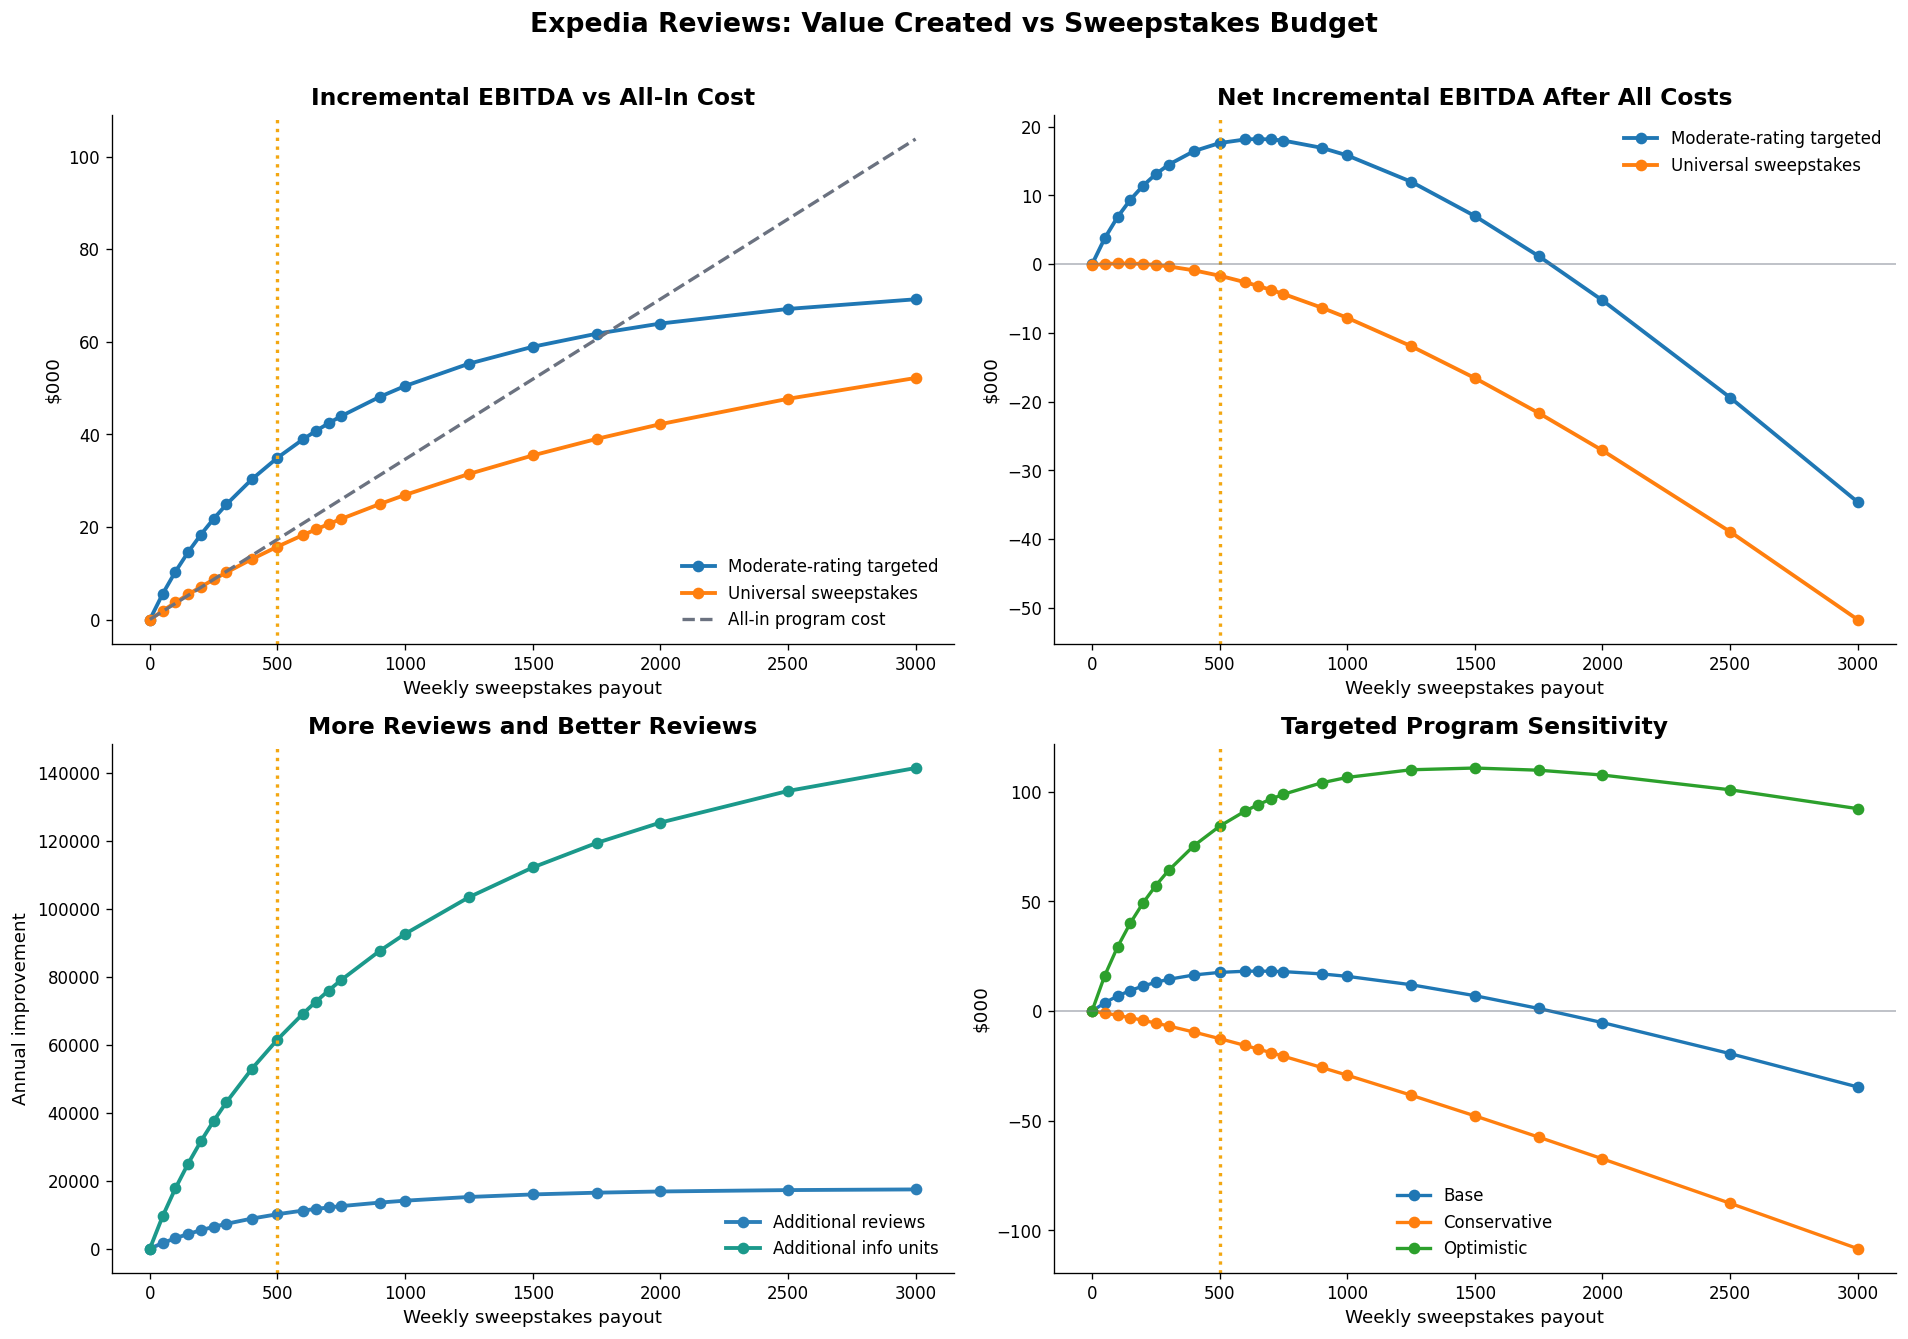

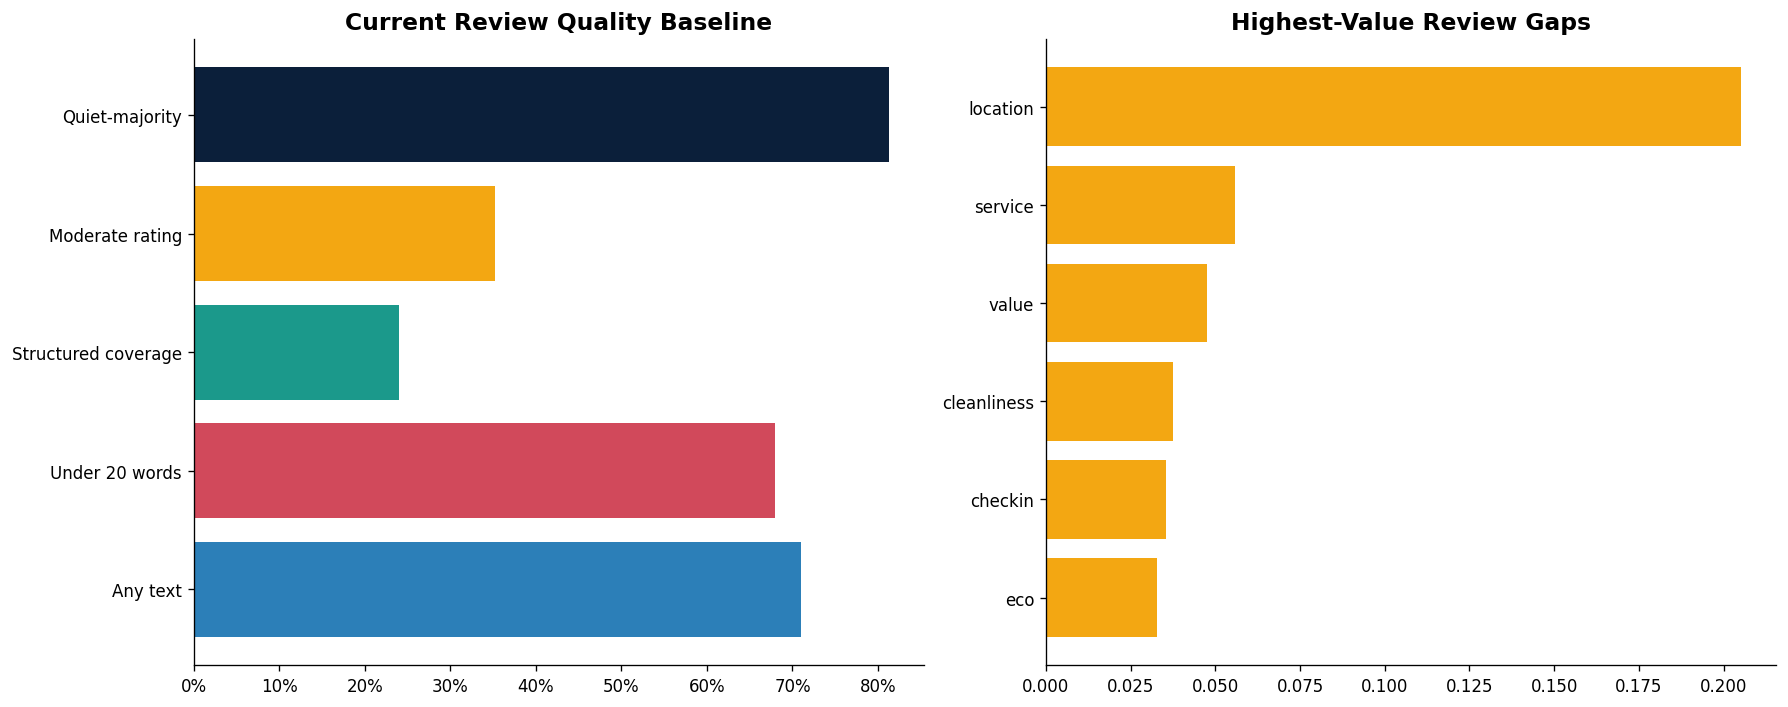

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for scenario_name, df in base_grid.groupby("scenario"):
    axes[0, 0].plot(
        df["weekly_payout"],
        df["incremental_ebitda"] / 1_000,
        marker="o",
        linewidth=2.3,
        label=scenario_name,
    )
    axes[0, 1].plot(
        df["weekly_payout"],
        df["net_incremental_ebitda"] / 1_000,
        marker="o",
        linewidth=2.3,
        label=scenario_name,
    )

axes[0, 0].plot(
    targeted_base["weekly_payout"],
    targeted_base["total_program_cost"] / 1_000,
    linestyle="--",
    linewidth=2.0,
    color=PALETTE["gray"],
    label="All-in program cost",
)

axes[1, 0].plot(
    targeted_base["weekly_payout"],
    targeted_base["additional_reviews"],
    marker="o",
    color=PALETTE["blue"],
    linewidth=2.3,
    label="Additional reviews",
)
axes[1, 0].plot(
    targeted_base["weekly_payout"],
    targeted_base["additional_info_units"],
    marker="o",
    color=PALETTE["teal"],
    linewidth=2.3,
    label="Additional info units",
)

for sensitivity_name, df in sensitivity_grid.groupby("sensitivity"):
    axes[1, 1].plot(
        df["weekly_payout"],
        df["net_incremental_ebitda"] / 1_000,
        marker="o",
        linewidth=2.0,
        label=sensitivity_name,
    )

axes[0, 0].set_title("Incremental EBITDA vs All-In Cost")
axes[0, 1].set_title("Net Incremental EBITDA After All Costs")
axes[1, 0].set_title("More Reviews and Better Reviews")
axes[1, 1].set_title("Targeted Program Sensitivity")

for ax in axes.flat:
    ax.axvline(500, color=PALETTE["gold"], linestyle=":", linewidth=2)
    ax.set_xlabel("Weekly sweepstakes payout")

axes[0, 0].set_ylabel("$000")
axes[0, 1].set_ylabel("$000")
axes[1, 0].set_ylabel("Annual improvement")
axes[1, 1].set_ylabel("$000")
axes[0, 1].axhline(0, color=PALETTE["gray"], linewidth=1, alpha=0.5)
axes[1, 1].axhline(0, color=PALETTE["gray"], linewidth=1, alpha=0.5)

axes[0, 0].legend(frameon=False)
axes[0, 1].legend(frameon=False)
axes[1, 0].legend(frameon=False)
axes[1, 1].legend(frameon=False)

fig.suptitle("Expedia Reviews: Value Created vs Sweepstakes Budget", fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
savefig(fig, "01_sweepstakes_financial_dashboard")

top_gaps = gap_topics.head(6).copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(
    ["Any text", "Under 20 words", "Structured coverage", "Moderate rating", "Quiet-majority"],
    [
        reviews["has_text"].mean(),
        (reviews["word_count"] < 20).mean(),
        reviews["structured_coverage_share"].mean(),
        reviews["moderate_rating"].mean(),
        reviews["quiet_majority_candidate"].mean(),
    ],
    color=[PALETTE["blue"], PALETTE["red"], PALETTE["teal"], PALETTE["gold"], PALETTE["navy"]],
)
axes[0].set_title("Current Review Quality Baseline")
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].barh(top_gaps["topic"], top_gaps["gap_score"], color=PALETTE["gold"])
axes[1].invert_yaxis()
axes[1].set_title("Highest-Value Review Gaps")
fig.tight_layout()
savefig(fig, "02_review_gap_snapshot")


## Rollout Framing: Pilot to Full Platform

,layer,annual_invites,affected_booking_base_share,sensitivity,framing
0,Pilot,1000000,0.1000,Base,Conservative initial launch; same scope as the...
1,Scaled rollout,10000000,0.6000,Base,Broader rollout across more verified post-stay...
2,Full platform base,25000000,1.0000,Base,Company-wide rollout using base-case review-to...
3,Full platform upside,25000000,1.0000,Optimistic,Company-wide upside view with stronger review-...


,layer,sensitivity,annual_invites,targeted_invites,weekly_payout,annual_prize_face_value,incremental_gross_bookings,incremental_revenue,incremental_ebitda,economic_cost,annual_ai_cost,total_program_cost,net_incremental_ebitda,revenue_to_program_cost_x
0,Pilot,Base,1000000,"351,891.9820",650,33800,"1,220,970.5856","137,926.4231","40,734.4450","22,477.0000",50.2154,"22,527.2154","18,207.2295",6.1227
1,Scaled rollout,Base,10000000,"3,518,919.8200",3000,156000,"4,476,634.8941","505,701.1576","149,351.0491","103,740.0000",470.6784,"104,210.6784","45,140.3707",4.8527
2,Full platform base,Base,25000000,"8,797,299.5499",3000,156000,"3,629,089.9886","409,958.6077","121,074.9614","103,740.0000","1,109.6248","104,849.6248","16,225.3366",3.9100
3,Full platform upside,Optimistic,25000000,"8,797,299.5499",15000,780000,"22,837,057.4171","2,579,778.4822","761,897.8460","386,100.0000","1,330.7540","387,430.7540","374,467.0920",6.6587


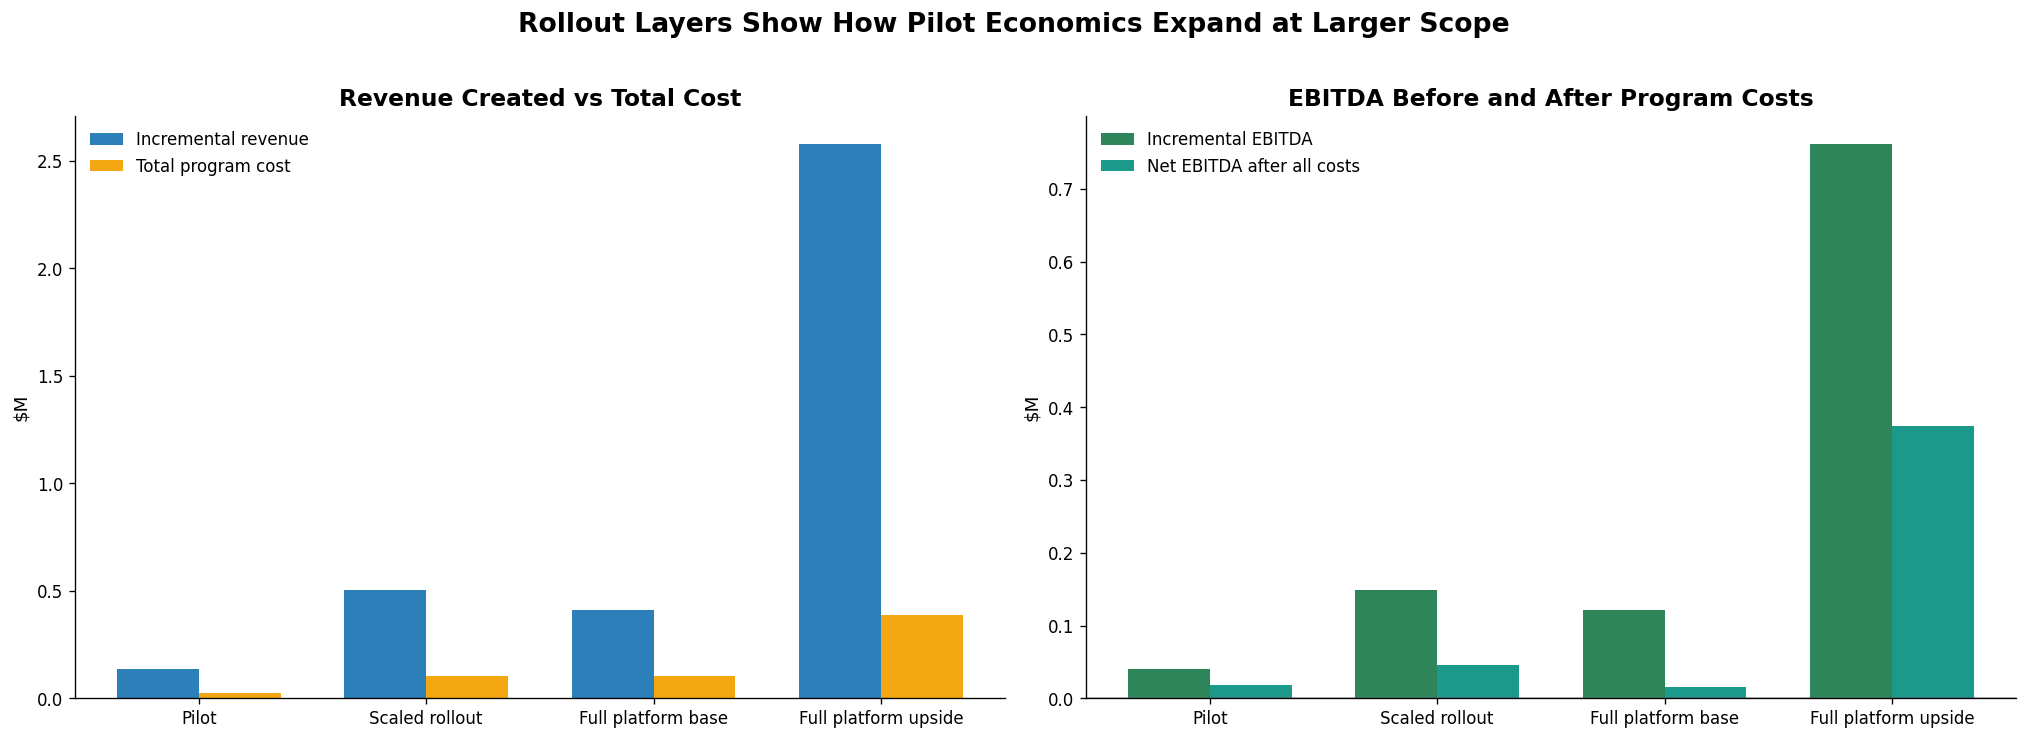

In [7]:
rollout_specs = [
    {
        "layer": "Pilot",
        "annual_invites": 1_000_000,
        "affected_booking_base_share": 0.10,
        "sensitivity": "Base",
        "weekly_payout_grid": weekly_payout_grid,
        "framing": "Conservative initial launch; same scope as the current base model.",
    },
    {
        "layer": "Scaled rollout",
        "annual_invites": 10_000_000,
        "affected_booking_base_share": 0.60,
        "sensitivity": "Base",
        "weekly_payout_grid": np.array([0, 250, 500, 750, 1000, 1250, 1500, 2000, 2500, 3000, 4000, 5000, 6500, 8000, 10000]),
        "framing": "Broader rollout across more verified post-stay touchpoints and review surfaces.",
    },
    {
        "layer": "Full platform base",
        "annual_invites": 25_000_000,
        "affected_booking_base_share": 1.00,
        "sensitivity": "Base",
        "weekly_payout_grid": np.array([0, 500, 1000, 1500, 2000, 2500, 3000, 4000, 5000, 6500, 8000, 10000, 12500, 15000, 20000, 25000, 30000]),
        "framing": "Company-wide rollout using base-case review-to-booking assumptions.",
    },
    {
        "layer": "Full platform upside",
        "annual_invites": 25_000_000,
        "affected_booking_base_share": 1.00,
        "sensitivity": "Optimistic",
        "weekly_payout_grid": np.array([0, 500, 1000, 1500, 2000, 2500, 3000, 4000, 5000, 6500, 8000, 10000, 12500, 15000, 20000, 25000, 30000]),
        "framing": "Company-wide upside view with stronger review-to-booking conversion assumptions.",
    },
]

rollout_rows = []
rollout_grids = []
for layer in rollout_specs:
    layer_results = pd.DataFrame(
        [
            evaluate_program(
                "Moderate-rating targeted",
                weekly_payout,
                layer["sensitivity"],
                annual_invites_override=layer["annual_invites"],
                affected_booking_base_share_override=layer["affected_booking_base_share"],
            )
            for weekly_payout in layer["weekly_payout_grid"]
        ]
    )
    layer_results["layer"] = layer["layer"]
    rollout_grids.append(layer_results)

    best_row = layer_results.sort_values("net_incremental_ebitda", ascending=False).iloc[0].to_dict()
    best_row["layer"] = layer["layer"]
    best_row["targeted_invites"] = layer["annual_invites"] * scenario_specs["Moderate-rating targeted"]["target_share"]
    best_row["framing"] = layer["framing"]
    rollout_rows.append(best_row)

rollout_summary = pd.DataFrame(rollout_rows)
rollout_budget_grid = pd.concat(rollout_grids, ignore_index=True)
rollout_assumptions = pd.DataFrame(
    [
        {
            "layer": layer["layer"],
            "annual_invites": layer["annual_invites"],
            "affected_booking_base_share": layer["affected_booking_base_share"],
            "sensitivity": layer["sensitivity"],
            "framing": layer["framing"],
        }
        for layer in rollout_specs
    ]
)

rollout_assumptions.to_csv(OUTPUT_DIR / "rollout_layer_assumptions.csv", index=False)
rollout_summary.to_csv(OUTPUT_DIR / "rollout_layer_summary.csv", index=False)
rollout_budget_grid.to_csv(OUTPUT_DIR / "rollout_layer_budget_grid.csv", index=False)

display(Markdown("## Rollout Framing: Pilot to Full Platform"))
display(rollout_assumptions)
display(
    rollout_summary[
        [
            "layer",
            "sensitivity",
            "annual_invites",
            "targeted_invites",
            "weekly_payout",
            "annual_prize_face_value",
            "incremental_gross_bookings",
            "incremental_revenue",
            "incremental_ebitda",
            "economic_cost",
            "annual_ai_cost",
            "total_program_cost",
            "net_incremental_ebitda",
            "revenue_to_program_cost_x",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
x = np.arange(len(rollout_summary))
width = 0.36

axes[0].bar(
    x - width / 2,
    rollout_summary["incremental_revenue"] / 1_000_000,
    width=width,
    color=PALETTE["blue"],
    label="Incremental revenue",
)
axes[0].bar(
    x + width / 2,
    rollout_summary["total_program_cost"] / 1_000_000,
    width=width,
    color=PALETTE["gold"],
    label="Total program cost",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(rollout_summary["layer"])
axes[0].set_ylabel("$M")
axes[0].set_title("Revenue Created vs Total Cost")
axes[0].legend(frameon=False)

axes[1].bar(
    x - width / 2,
    rollout_summary["incremental_ebitda"] / 1_000_000,
    width=width,
    color=PALETTE["green"],
    label="Incremental EBITDA",
)
axes[1].bar(
    x + width / 2,
    rollout_summary["net_incremental_ebitda"] / 1_000_000,
    width=width,
    color=PALETTE["teal"],
    label="Net EBITDA after all costs",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(rollout_summary["layer"])
axes[1].set_ylabel("$M")
axes[1].set_title("EBITDA Before and After Program Costs")
axes[1].axhline(0, color=PALETTE["gray"], linewidth=1, alpha=0.5)
axes[1].legend(frameon=False)

fig.suptitle("Rollout Layers Show How Pilot Economics Expand at Larger Scope", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "03_rollout_layers")


## Slide-Ready Full Platform Business Case

,layer,sensitivity,weekly_payout,annual_prize_face_value,economic_cost,annual_ai_cost,total_program_cost,ranking_calls,cost_per_1000_calls,additional_reviews,additional_info_units,incremental_gross_bookings,incremental_revenue,incremental_ebitda,net_incremental_ebitda,revenue_to_program_cost_x,ebitda_to_program_cost_x,ai_cost_share_of_program_cost,payback_months_on_ebitda
2,Full platform base,Base,3000,156000,"103,740.0000","1,109.6248","104,849.6248","1,849,374.7147",0.6000,"89,591.1698","518,910.5890","3,629,089.9886","409,958.6077","121,074.9614","16,225.3366",3.9100,1.1547,0.0106,10.3919
3,Full platform upside,Optimistic,15000,780000,"386,100.0000","1,330.7540","387,430.7540","2,217,923.3602",0.6000,"396,715.0411","2,269,140.2963","22,837,057.4171","2,579,778.4822","761,897.8460","374,467.0920",6.6587,1.9665,0.0034,6.1021


## Full Platform Value Bridge

,case,weekly_payout,annual_prize_face_value,expected_value_per_entry,guaranteed_equivalent_reward,final_completion_rate,additional_reviews,additional_info_units,total_uplift_bps,incremental_gross_bookings,incremental_revenue,incremental_ebitda,economic_cost,annual_ai_cost,total_program_cost,net_incremental_ebitda
0,Full platform base,3000,156000,0.0476,0.0456,0.1752,"89,591.1698","518,910.5890",0.4327,"3,629,089.9886","409,958.6077","121,074.9614","103,740.0000","1,109.6248","104,849.6248","16,225.3366"
1,Full platform upside,15000,780000,0.1552,0.2532,0.2101,"396,715.0411","2,269,140.2963",2.7230,"22,837,057.4171","2,579,778.4822","761,897.8460","386,100.0000","1,330.7540","387,430.7540","374,467.0920"


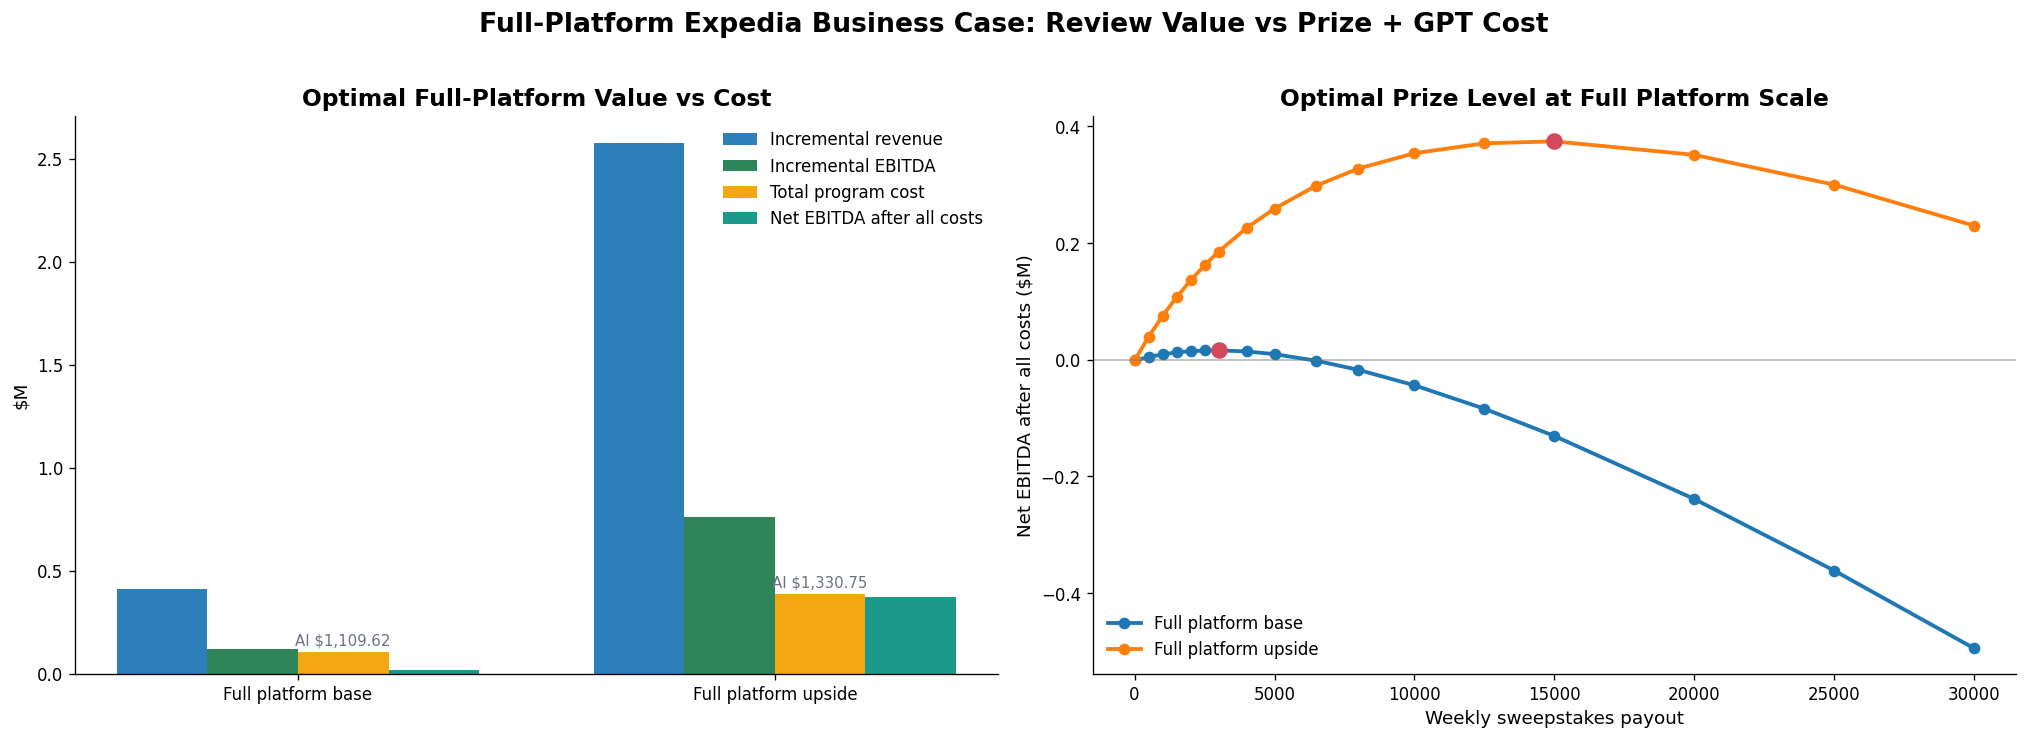

In [8]:
full_platform_cases = rollout_summary.loc[
    rollout_summary["layer"].isin(["Full platform base", "Full platform upside"])
].copy()
full_platform_budget_grid = rollout_budget_grid.loc[
    rollout_budget_grid["layer"].isin(["Full platform base", "Full platform upside"])
].copy()

full_platform_value_bridge = []
for layer_name in ["Full platform base", "Full platform upside"]:
    row = full_platform_cases.loc[full_platform_cases["layer"] == layer_name].iloc[0]
    full_platform_value_bridge.append(
        {
            "case": layer_name,
            "weekly_payout": row["weekly_payout"],
            "annual_prize_face_value": row["annual_prize_face_value"],
            "expected_value_per_entry": row["expected_value_per_entry"],
            "guaranteed_equivalent_reward": row["guaranteed_equivalent_reward"],
            "final_completion_rate": row["final_completion_rate"],
            "additional_reviews": row["additional_reviews"],
            "additional_info_units": row["additional_info_units"],
            "total_uplift_bps": row["total_uplift_bps"],
            "incremental_gross_bookings": row["incremental_gross_bookings"],
            "incremental_revenue": row["incremental_revenue"],
            "incremental_ebitda": row["incremental_ebitda"],
            "economic_cost": row["economic_cost"],
            "annual_ai_cost": row["annual_ai_cost"],
            "total_program_cost": row["total_program_cost"],
            "net_incremental_ebitda": row["net_incremental_ebitda"],
        }
    )

full_platform_value_bridge = pd.DataFrame(full_platform_value_bridge)

slide_metrics = full_platform_cases[
    [
        "layer",
        "sensitivity",
        "weekly_payout",
        "annual_prize_face_value",
        "economic_cost",
        "annual_ai_cost",
        "total_program_cost",
        "ranking_calls",
        "cost_per_1000_calls",
        "additional_reviews",
        "additional_info_units",
        "incremental_gross_bookings",
        "incremental_revenue",
        "incremental_ebitda",
        "net_incremental_ebitda",
        "revenue_to_program_cost_x",
        "ebitda_to_program_cost_x",
        "ai_cost_share_of_program_cost",
        "payback_months_on_ebitda",
    ]
].copy()

slide_metrics.to_csv(OUTPUT_DIR / "full_platform_slide_metrics.csv", index=False)
full_platform_budget_grid.to_csv(OUTPUT_DIR / "full_platform_budget_grid.csv", index=False)
full_platform_value_bridge.to_csv(OUTPUT_DIR / "full_platform_value_bridge.csv", index=False)

display(Markdown("## Slide-Ready Full Platform Business Case"))
display(slide_metrics)
display(Markdown("## Full Platform Value Bridge"))
display(full_platform_value_bridge)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
x = np.arange(len(full_platform_cases))
width = 0.19

axes[0].bar(
    x - 1.5 * width,
    full_platform_cases["incremental_revenue"] / 1_000_000,
    width=width,
    color=PALETTE["blue"],
    label="Incremental revenue",
)
axes[0].bar(
    x - 0.5 * width,
    full_platform_cases["incremental_ebitda"] / 1_000_000,
    width=width,
    color=PALETTE["green"],
    label="Incremental EBITDA",
)
axes[0].bar(
    x + 0.5 * width,
    full_platform_cases["total_program_cost"] / 1_000_000,
    width=width,
    color=PALETTE["gold"],
    label="Total program cost",
)
axes[0].bar(
    x + 1.5 * width,
    full_platform_cases["net_incremental_ebitda"] / 1_000_000,
    width=width,
    color=PALETTE["teal"],
    label="Net EBITDA after all costs",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(full_platform_cases["layer"])
axes[0].set_ylabel("$M")
axes[0].set_title("Optimal Full-Platform Value vs Cost")
axes[0].legend(frameon=False)

for idx, row in full_platform_cases.reset_index(drop=True).iterrows():
    axes[0].text(
        idx + 0.5 * width,
        row["total_program_cost"] / 1_000_000 + 0.02,
        f"AI {usd(row['annual_ai_cost'])}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=PALETTE["gray"],
    )

for layer_name, df in full_platform_budget_grid.groupby("layer"):
    axes[1].plot(
        df["weekly_payout"],
        df["net_incremental_ebitda"] / 1_000_000,
        marker="o",
        linewidth=2.3,
        label=layer_name,
    )
    best = df.sort_values("net_incremental_ebitda", ascending=False).iloc[0]
    axes[1].scatter(
        best["weekly_payout"],
        best["net_incremental_ebitda"] / 1_000_000,
        s=80,
        color=PALETTE["red"],
        zorder=3,
    )

axes[1].axhline(0, color=PALETTE["gray"], linewidth=1, alpha=0.5)
axes[1].set_xlabel("Weekly sweepstakes payout")
axes[1].set_ylabel("Net EBITDA after all costs ($M)")
axes[1].set_title("Optimal Prize Level at Full Platform Scale")
axes[1].legend(frameon=False)

fig.suptitle("Full-Platform Expedia Business Case: Review Value vs Prize + GPT Cost", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "04_full_platform_business_case")


In [9]:
current_ui = targeted_base.loc[targeted_base["weekly_payout"] == 500].iloc[0]
universal_optimal = base_optima.loc[base_optima["scenario"] == "Universal sweepstakes"].iloc[0]
full_platform_base = rollout_summary.loc[rollout_summary["layer"] == "Full platform base"].iloc[0]
full_platform_upside = rollout_summary.loc[rollout_summary["layer"] == "Full platform upside"].iloc[0]

optimization_summary = pd.DataFrame(
    [
        {"view": "Base optimal targeted program", **targeted_optimal.to_dict()},
        {"view": "Current UI payout ($500/week)", **current_ui.to_dict()},
        {"view": "Base optimal universal program", **universal_optimal.to_dict()},
        {"view": "Full platform base", **full_platform_base.to_dict()},
        {"view": "Full platform upside", **full_platform_upside.to_dict()},
    ]
)
optimization_summary.to_csv(OUTPUT_DIR / "optimization_summary.csv", index=False)

recommendation = (
    "## Recommendation\n\n"
    f"- **Pilot recommendation**: about **${int(targeted_optimal['weekly_payout'])}/week** for the moderate-rating targeted program.\n"
    f"- In the pilot-scale base case, that corresponds to **{usd(targeted_optimal['incremental_revenue'])}** of incremental revenue, **{usd(targeted_optimal['incremental_ebitda'])}** of incremental EBITDA, **{usd(targeted_optimal['total_program_cost'])}** of total program cost, and **{usd(targeted_optimal['net_incremental_ebitda'])}** of all-in net EBITDA.\n"
    f"- The current **$500/week** demo design is still close to optimal, with about **{usd(current_ui['net_incremental_ebitda'])}** of all-in net EBITDA in the base case.\n"
    f"- The all-in **GPT-4o mini** ranking cost is tiny relative to the prize pool: about **{usd(ai_cost_per_call)} per ranking call**, or about **{usd(ai_cost_per_call * 1000)} per 1,000 ranking calls** under the selected token assumptions.\n"
    f"- At **full platform base** scale, the model lands near **${int(full_platform_base['weekly_payout'])}/week**, creating about **{usd(full_platform_base['incremental_gross_bookings'])}** of incremental gross bookings, **{usd(full_platform_base['incremental_revenue'])}** of incremental revenue, and **{usd(full_platform_base['net_incremental_ebitda'])}** of all-in net EBITDA on **{usd(full_platform_base['total_program_cost'])}** of program cost.\n"
    f"- At **full platform upside** scale, the model lands near **${int(full_platform_upside['weekly_payout'])}/week**, creating about **{usd(full_platform_upside['incremental_gross_bookings'])}** of incremental gross bookings, **{usd(full_platform_upside['incremental_revenue'])}** of incremental revenue, and **{usd(full_platform_upside['net_incremental_ebitda'])}** of all-in net EBITDA on **{usd(full_platform_upside['total_program_cost'])}** of program cost.\n"
    f"- Best pitch framing: lead with the base full-platform case showing that **incremental revenue is about {full_platform_base['revenue_to_program_cost_x']:.1f}x total program cost**, then use the upside case to show how much larger the value becomes if Expedia believes review quality has a stronger booking effect."
)

display(Markdown(recommendation))
display(Markdown("## Optimization Summary"))
display(
    optimization_summary[
        [
            "view",
            "weekly_payout",
            "annual_prize_face_value",
            "additional_reviews",
            "additional_info_units",
            "incremental_revenue",
            "incremental_ebitda",
            "economic_cost",
            "annual_ai_cost",
            "total_program_cost",
            "net_incremental_ebitda",
        ]
    ]
)


## Recommendation

- **Pilot recommendation**: about **$650/week** for the moderate-rating targeted program.
- In the pilot-scale base case, that corresponds to **$137,926.42** of incremental revenue, **$40,734.44** of incremental EBITDA, **$22,527.22** of total program cost, and **$18,207.23** of all-in net EBITDA.
- The current **$500/week** demo design is still close to optimal, with about **$17,622.81** of all-in net EBITDA in the base case.
- The all-in **GPT-4o mini** ranking cost is tiny relative to the prize pool: about **$0.00 per ranking call**, or about **$0.60 per 1,000 ranking calls** under the selected token assumptions.
- At **full platform base** scale, the model lands near **$3000/week**, creating about **$3,629,089.99** of incremental gross bookings, **$409,958.61** of incremental revenue, and **$16,225.34** of all-in net EBITDA on **$104,849.62** of program cost.
- At **full platform upside** scale, the model lands near **$15000/week**, creating about **$22,837,057.42** of incremental gross bookings, **$2,579,778.48** of incremental revenue, and **$374,467.09** of all-in net EBITDA on **$387,430.75** of program cost.
- Best pitch framing: lead with the base full-platform case showing that **incremental revenue is about 3.9x total program cost**, then use the upside case to show how much larger the value becomes if Expedia believes review quality has a stronger booking effect.

## Optimization Summary

,view,weekly_payout,annual_prize_face_value,additional_reviews,additional_info_units,incremental_revenue,incremental_ebitda,economic_cost,annual_ai_cost,total_program_cost,net_incremental_ebitda
0,Base optimal targeted program,650,33800,"11,681.4974","72,641.5635","137,926.4231","40,734.4450","22,477.0000",50.2154,"22,527.2154","18,207.2295"
1,Current UI payout ($500/week),500,26000,"10,133.0661","61,546.9268","118,380.6801","34,961.9108","17,290.0000",49.1006,"17,339.1006","17,622.8102"
2,Base optimal universal program,100,5200,"2,802.9432","19,409.2630","12,557.7631","3,708.7420","3,458.0000",146.0181,"3,604.0181",104.7238
3,Full platform base,3000,156000,"89,591.1698","518,910.5890","409,958.6077","121,074.9614","103,740.0000","1,109.6248","104,849.6248","16,225.3366"
4,Full platform upside,15000,780000,"396,715.0411","2,269,140.2963","2,579,778.4822","761,897.8460","386,100.0000","1,330.7540","387,430.7540","374,467.0920"
